# 최적화 함수 Optimizer

지금까지는 손실 함수, 미분, 기울기, 오차역전파까지 살펴보았다.  
이렇게 구한 기울기를 사용해서 가중치를 실제로 어떻게 바꿀지 살펴볼 차례이다.

- 역전파: 각 가중치에 대한 기울기를 계산하는 단계
- optimizer: 계산된 기울기를 바탕으로 가중치를 업데이트하는 단계

즉, optimizer는 기울기를 보고 얼마나, 어떤 방식으로 이동할지를 정하는 도구이다.

> 일반적인 2차 손실 함수인 MSE 같은 경우, 포물선 형태의 convex 함수로 생각할 수 있다.
>
> 이런 경우에는 최저점이 하나의 global minimum으로 표현되기 쉽다.
>
> 하지만 복잡한 비선형 모델이나 다층 신경망에서는 손실 함수가 항상 convex하지 않다.
> 그래서 학습 도중에 방향이 흔들리거나, 천천히 내려가거나, 지역적인 낮은 지점에 머무는 문제가 생길 수 있다.

그래서 optimizer는 단순히 "내려간다"가 아니라, 더 빠르고 더 안정적으로 내려가도록 여러 전략을 사용한다.

![](https://blog.kakaocdn.net/dn/b5qQXn/btrwZZbnLEh/33NmNUWcEOfr9Q7C2UOPOK/img.png)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 01. SGD (Stochastic Gradient Descent)

SGD는 가장 기본적인 optimizer이다.  
현재 위치에서 계산한 기울기를 보고, 그 반대 방향으로 조금 이동한다.

핵심 아이디어는 아주 단순하다.

- 기울기가 크면 더 많이 이동한다.
- 기울기가 작으면 덜 이동한다.
- learning rate는 한 번에 얼마나 이동할지 정하는 값이다.

**수식**
- $ \theta_{t+1} = \theta_t - \alpha \nabla_{\theta}L(\theta_t) $

여기서:
- $\theta_t$: 현재 파라미터
- $\alpha$: 학습률
- $\nabla_{\theta}L(\theta_t)$: 현재 위치에서의 기울기

아래 예시는 손실 함수 $L(w)=w^2$ 위에서 SGD가 어떻게 내려가는지 단순하게 보여준다.  
최저점은 $w=0$ 이다.


[1.8, 1.44, 1.152, 0.9216, 0.7372799999999999, 0.5898239999999999, 0.4718591999999999, 0.37748735999999994, 0.30198988799999993, 0.24159191039999994, 0.19327352831999994]


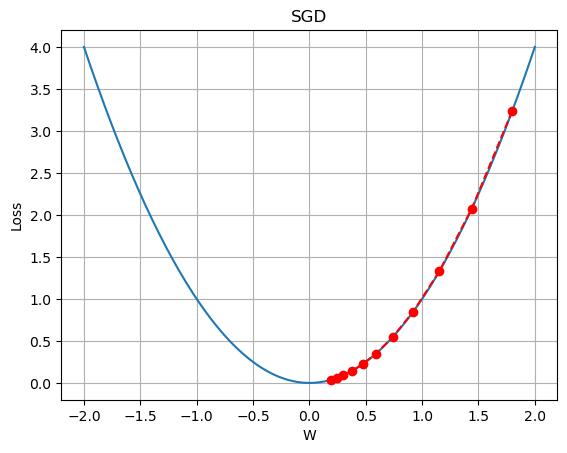

In [6]:
def loss(w):
    return w ** 2

def gradient(w):
    return 2 * w

def sgd(w=1.8, lr=0.1, epochs=10):
    history = [float(w)]
    
    for epochs in range(epochs):
        grad = gradient(w)
        w -= lr * grad
        history.append(float(w))
        
    return history

history = sgd()
print(history)

# 시각화
W = np.linspace(-2, 2, 200)
plt.plot(W, loss(W), label='Loss Function')
plt.plot(history, loss(np.array(history)), 'ro--', label='SGD Path')
plt.xlabel('W')
plt.ylabel('Loss')
plt.grid()
plt.title('SGD')
plt.show()

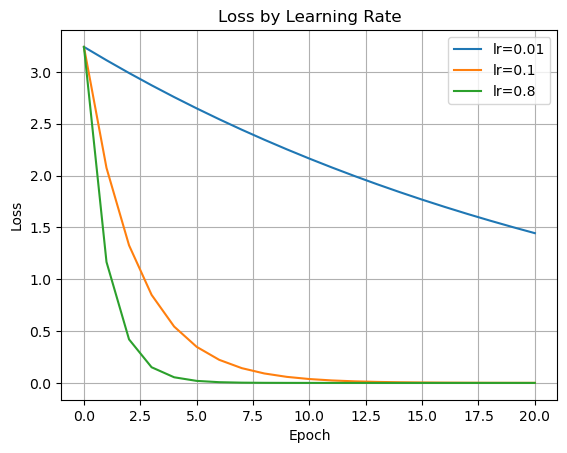

In [8]:
# 학습률에 따른 loss 변화 비교
learning_rates = [0.01, 0.1, 0.8]
history_list = [sgd(lr=lr, epochs=20) for lr in learning_rates]

for i, hist in enumerate(history_list):
    loss_history = [loss(w) for w in hist]
    plt.plot(loss_history, label=f'lr={learning_rates[i]}')
    
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss by Learning Rate')
plt.legend()
plt.grid()
plt.show()

## 02. Momentum

SGD는 매 step마다 현재 기울기만 보고 움직인다.  
그래서 방향이 자주 바뀌는 구간에서는 좌우로 흔들릴 수 있다.

Momentum은 이전까지의 이동 방향을 조금 기억해서, 관성처럼 다음 이동에 반영하는 방식이다.

- 현재 기울기만 보는 것이 아니라
- 이전 이동 방향도 함께 참고한다.
- 그래서 흔들림을 줄이고 더 빠르게 내려갈 수 있다.

**수식**
- $ v_t = \beta v_{t-1} + \alpha \nabla_{\theta}L(\theta_t) $
- $ \theta_{t+1} = \theta_t - v_t $

여기서:
- $v_t$: 속도처럼 누적되는 값
- $\beta$: 이전 방향을 얼마나 기억할지 정하는 값
- $\alpha$: 학습률

쉽게 말하면, Momentum은 "방금 전까지 가던 방향을 조금 이어서 가는 방식"이다.


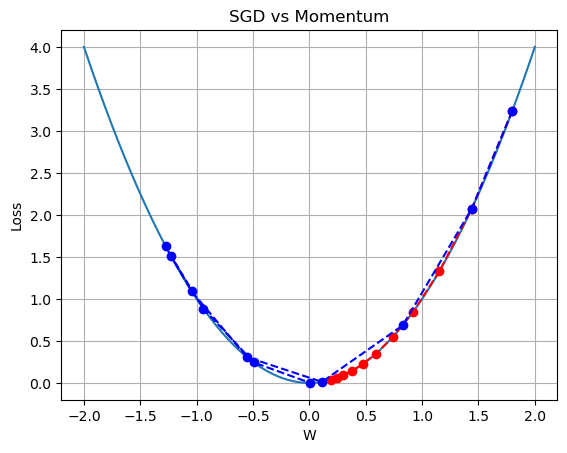

In [12]:
def momentum(w=1.8, lr=0.1, epochs=10, beta=0.9):
    history = [float(w)]
    v = 0.0
    v_history = [float(v)]
    
    for epochs in range(epochs):
        grad = gradient(w)
        v = beta * v - lr * grad
        w += v
        history.append(float(w))
        v_history.append(float(v))
        
    return history, v_history

sgd_history = sgd()
momentum_history, v_history = momentum()

# 시각화
x_vals = np.linspace(-2, 2, 200)
plt.plot(x_vals, loss(x_vals), label='Loss Function')
plt.plot(sgd_history, loss(np.array(sgd_history)), 'ro--', label='SGD Path')
plt.plot(momentum_history, loss(np.array(momentum_history)), 'bo--', label='Momentum Path')
plt.xlabel('W')
plt.ylabel('Loss')
plt.grid()
plt.title('SGD vs Momentum')
plt.show()

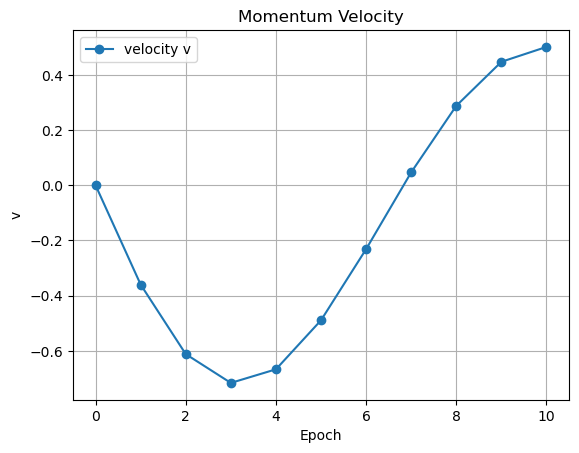

In [13]:
# 속도(v) 시긱화
plt.plot(v_history, marker='o', label='velocity v')
plt.xlabel('Epoch')
plt.ylabel('v')
plt.title('Momentum Velocity')
plt.legend()
plt.grid()
plt.show()

## 03. AdaGrad

AdaGrad는 모든 파라미터에 같은 학습률을 쓰는 대신,  
파라미터마다 학습률을 다르게 조절하는 아이디어를 사용한다.

- 자주 크게 업데이트된 파라미터는 학습률을 더 줄이고
- 덜 업데이트된 파라미터는 상대적으로 더 크게 움직이게 한다.

그래서 희소한 특징이 있는 문제에서는 도움이 될 수 있다.  
하지만 기울기 제곱합이 계속 누적되기 때문에, 학습이 진행될수록 학습률이 너무 작아질 수 있다.

**수식**
- $ r_t = r_{t-1} + (\nabla_{\theta}L(\theta_t))^2 $
- $ \theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{r_t}+\epsilon} \nabla_{\theta}L(\theta_t) $

여기서:
- $r_t$: 기울기 제곱의 누적합
- $\epsilon$: 0으로 나누는 문제를 막기 위한 아주 작은 값

즉, AdaGrad는 "많이 움직였던 방향은 점점 조심스럽게 이동"하는 방식이다.


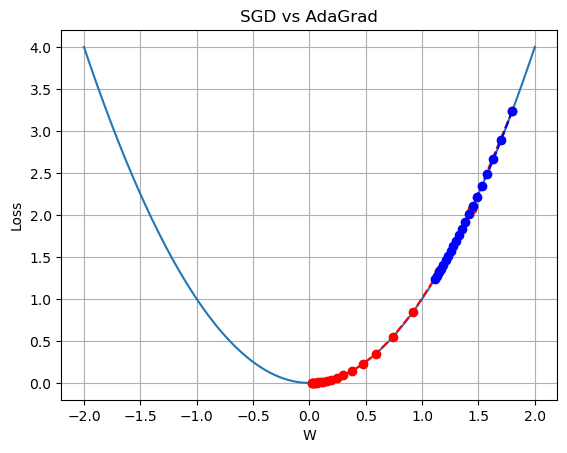

In [17]:
# r : 기울기 제곱의 누적합
# epsilon : 분모가 0이 되는 것을 막기 위한 작은 값

def adagrad(w=1.8, lr=0.1, epochs=20, epsilon=1e-8):
    history = [float(w)]
    r = 0.0
    
    for epochs in range(epochs):
        grad = gradient(w)
        r += grad ** 2
        w -= (lr / (np.sqrt(r) + epsilon)) * grad
        history.append(float(w))
        
    return history

sgd_history = sgd(lr=0.1, epochs=20)
adagrad_history = adagrad()

# 시각화
x_vals = np.linspace(-2, 2, 200)
plt.plot(x_vals, loss(x_vals), label='Loss Function')
plt.plot(sgd_history, loss(np.array(sgd_history)), 'ro--', label='SGD Path')
plt.plot(adagrad_history, loss(np.array(adagrad_history)), 'bo--', label='Adagrad Path')
plt.xlabel('W')
plt.ylabel('Loss')
plt.grid()
plt.title('SGD vs AdaGrad')
plt.show()

## 04. RMSProp

RMSProp은 AdaGrad와 비슷하게 학습률을 조절하지만,  
과거의 모든 정보를 똑같이 계속 누적하지 않고 최근 기울기 정보를 더 많이 반영한다.

이유는 간단하다.

- AdaGrad는 누적합이 계속 커져서 학습률이 너무 작아질 수 있다.
- RMSProp은 오래된 정보는 조금씩 잊고, 최근 정보를 더 많이 본다.
- 그래서 학습률이 지나치게 빠르게 줄어드는 문제를 완화할 수 있다.

**지수 이동 평균**
- 최근 값에 더 큰 비중을 주고
- 오래된 값은 점점 덜 반영하는 평균 방식이다.

예를 들면:
- $\beta=0.9$ 이면 과거 정보를 많이 기억한다.
- $\beta=0.5$ 이면 최근 정보 반영 비중이 더 커진다.
- $\beta=0$ 이면 현재 값만 본다.

**수식**
$
\begin{aligned}
&r_t = \beta r_{t-1} + (1 - \beta) g_t^2 \\[8pt]
&\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{r_t} + \epsilon} g_t
\end{aligned}
$


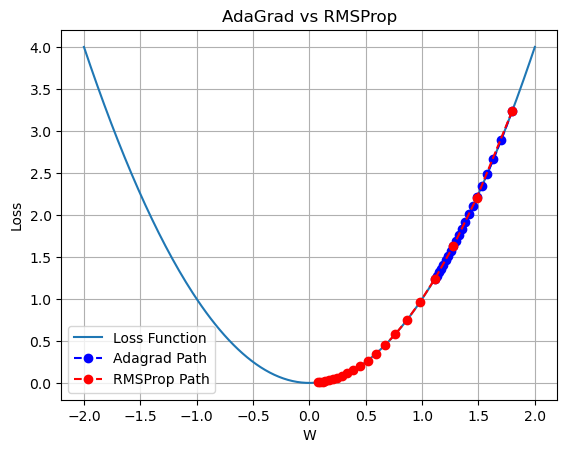

In [19]:
# r : 최근 기울기 제곱의 이동 평균
# beta : 과거 정보를 얼마나 기억할지 정하는 값

def rmsprop(w=1.8, lr=0.1, epochs=20, epsilon=1e-8, beta=0.9):
    history = [float(w)]
    r = 0.0
    
    for epochs in range(epochs):
        grad = gradient(w)
        r = beta * r + (1 - beta) * (grad ** 2)
        w -= (lr / (np.sqrt(r) + epsilon)) * grad
        history.append(float(w))
        
    return history

adagrad_history = adagrad()
rmsprop_history = rmsprop()

# 시각화
x_vals = np.linspace(-2, 2, 200)
plt.plot(x_vals, loss(x_vals), label='Loss Function')
plt.plot(adagrad_history, loss(np.array(adagrad_history)), 'bo--', label='Adagrad Path')
plt.plot(rmsprop_history, loss(np.array(rmsprop_history)), 'ro--', label='RMSProp Path')
plt.xlabel('W')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.title('AdaGrad vs RMSProp')
plt.show()

## 05. Adam

Adam은 딥러닝에서 매우 자주 쓰이는 optimizer이다.  
이유는 Momentum과 RMSProp의 장점을 함께 사용하기 때문이다.

- Momentum처럼 이전 기울기 방향을 기억하고
- RMSProp처럼 학습률도 적응적으로 조절한다

Adam은 두 가지 값을 추적한다.

| 값 | 의미 | 역할 |
| --- | --- | --- |
| $m_t$ | 1차 모멘텀 | 기울기의 평균 방향 |
| $v_t$ | 2차 모멘텀 | 기울기 제곱의 평균 크기 |

**수식**
1. 1차 모멘텀 업데이트  
   $ m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t $

2. 2차 모멘텀 업데이트  
   $ v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2 $

3. 바이어스 보정  
   $ \hat{m}_t = \frac{m_t}{1-\beta_1^t} $,  
   $ \hat{v}_t = \frac{v_t}{1-\beta_2^t} $

4. 파라미터 업데이트  
   $ \theta_{t+1} = \theta_t - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} $

즉, Adam은 "방향도 기억하고, 이동 크기도 자동으로 조절하는 방식"이다.


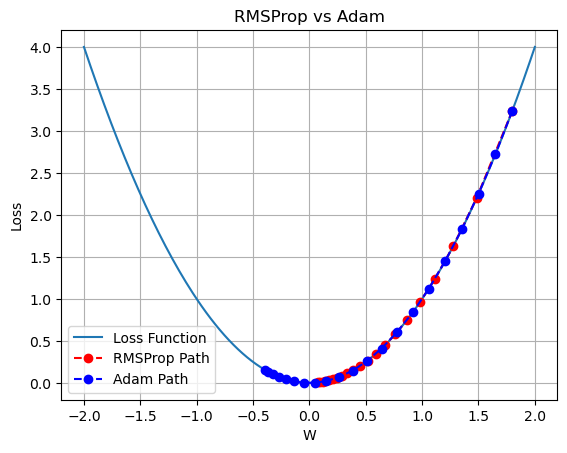

In [21]:
# m : 기울기의 이동 평균(방향)
# v : 기울기의 제곱의 이동 평균(크기)
# beta1, beta2: 과거 정보를 얼마나 반영할지 정하는 값

def adam(w=1.8, lr=0.15, epochs=20, epsilon=1e-8, beta1=0.9, beta2=0.999):
    history = [float(w)]
    m = 0.0
    v = 0.0
    
    for t in range(1, epochs+1):
        grad = gradient(w)
        
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)
        
        # 초반에 m, v가 너무 작게 시작하는 문제를 보정
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        
        w -= lr * m_hat / (np.sqrt(v_hat) + epsilon)
        
        history.append(float(w))
        
    return history

rmsprop_history = rmsprop()
adam_history = adam()

# 시각화
x_vals = np.linspace(-2, 2, 200)
plt.plot(x_vals, loss(x_vals), label='Loss Function')
plt.plot(rmsprop_history, loss(np.array(rmsprop_history)), 'ro--', label='RMSProp Path')
plt.plot(adam_history, loss(np.array(adam_history)), 'bo--', label='Adam Path')
plt.xlabel('W')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.title('RMSProp vs Adam')
plt.show()

## torch.optim

PyTorch에서 실제 모델 학습에 optimizer를 어떻게 적용하는지 보자.

| Optimizer  | 설명 |
| ---------- | ---- |
| `SGD`      | 가장 기본적인 확률적 경사 하강법 |
| `Adam`     | 모멘텀 + 적응적 학습률 조절 |
| `AdamW`    | Adam에서 weight decay를 더 분리해 다루는 방식 |
| `RMSprop`  | 최근 기울기 제곱 평균으로 학습률 조절 |
| `Adagrad`  | 파라미터별로 학습률을 다르게 조절 |
| `Adadelta` | Adagrad의 학습률 감소 문제를 보완 |
| `NAdam`    | Adam + Nesterov momentum |
| `LBFGS`    | 2차 계열에 가까운 최적화 방식 |

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

# 데이터 생성
torch.manual_seed(42)

X = torch.rand(100, 5) * 10
true_W = torch.tensor([[2.0], [1.5], [-3.0], [0.5], [4.0]])
true_b = torch.tensor(7.0)
y = X @ true_W + true_b + torch.randn(100, 1)

print(X.shape, y.shape)

torch.Size([100, 5]) torch.Size([100, 1])


In [23]:
# 모델 생성 함수
# 입력 값 5개를 받아서 은닉층(10개 -> 8개)을 거친 뒤 최종적으로 1개의 값을 예측하는 신경망
def get_model():
    # 레이어를 순서대로 쌓아놓은 모델(가장 단순한 모델 구성 방식)
    return nn.Sequential(
        nn.Linear(5, 10),   # 입력 특성 5개 -> 첫 번째 은닉층 노드 10개
        nn.ReLU(),          # 활성화 함수 : 음수는 0으로 양수는 그대로
        nn.Linear(10,8),    # 첫 번째 은닉층 10개 -> 두 번째 은닉층 8개
        nn.ReLU(),
        nn.Linear(8,1)      # 두 번째 은닉층 8개 -> 최종 출력 1개
    )
    
# 손실 함수
criterion = nn.MSELoss()

# optimizer 차이를 보기 위해 같은 구조의 모델을 하나씩 생성
model_sgd = get_model()
model_adam = get_model()

# optimizer 설정
optim_sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
optim_adam = optim.Adam(model_adam.parameters(), lr=0.01)

In [24]:
# 모델 학습
# epoch만큼 반복하면서 예측 -> 손실 계산 -> 역전파 -> 파라미터 업데이트 수행
def train(epochs, model, optimizer, losses):
    for epoch in range(epochs):
        optimizer.zero_grad()           # 이전 stop에서 계산 된 gradient 초기화
        y_hat = model(X)                # 현재 모델로 입력 X에 대한 예측값 계산
        loss = criterion(y_hat, y)      # 예측 값과 실제 값의 차이로 손실 계산
        loss.backward()                 # 손실을 기준으로 각 파라미터의 gradient 계산
        optimizer.step()                # optimizer가 gradient를 이용해 파라미터 업데이트
        losses.append(loss.item())      # 현재 epoch의 손실 값을 숫자 형태로 저장
    return losses

# 학습 반복 횟수
epochs = 100

# SGD로 학습했을 때의 손실 기록
losses_sgd = train(epochs, model_sgd, optim_sgd, [])

# Adam으로 학습했을 때의 손실 기록
losses_adam = train(epochs, model_adam, optim_adam, [])

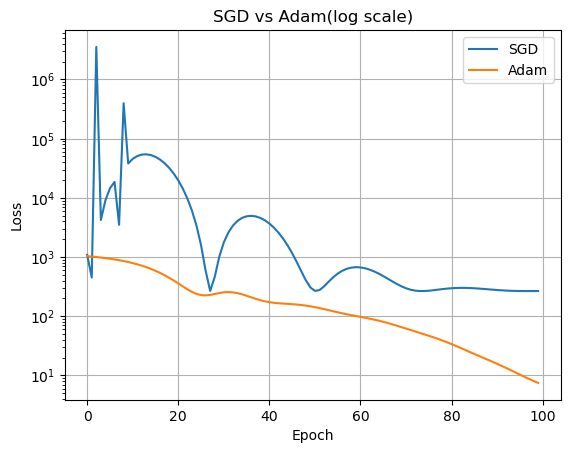

In [26]:
# 시각화
plt.plot(losses_sgd, label='SGD')
plt.plot(losses_adam, label='Adam')
plt.yscale('log')   # y축을 로그 스케일로 변경
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD vs Adam(log scale)')
plt.grid()
plt.show()

## 정리

- optimizer는 기울기를 보고 가중치를 어떻게 업데이트할지 정한다.
- SGD는 가장 기본적인 방식이다.
- Momentum은 이전 이동 방향을 기억한다.
- AdaGrad는 파라미터별로 학습률을 조절한다.
- RMSProp은 최근 정보에 더 비중을 둔다.
- Adam은 Momentum과 RMSProp의 장점을 함께 사용한다.

실제 실무나 실습에서는 `Adam`, `AdamW`, `SGD`를 자주 보게 된다.  
하지만 여기서 중요한 것은 기울기를 어떻게 더 잘 반영하려고 발전해 왔는가를 이해하는 것이다.